In [3]:
import pandas as pd
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams
import time

# Get all active NBA teams
all_teams = teams.get_teams()

# Initialize an empty list to store DataFrames for each team
shot_dataframes = []

# Loop through each active team
for team in all_teams:
    team_id = team['id']
    team_name = team['full_name']
    
    print(f"Fetching shot data for {team_name}...")
    
    # Retry mechanism: Try up to 3 times per team if the server times out
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # Fetch shot chart detail (increased timeout to 60 seconds)
            shot_chart = shotchartdetail.ShotChartDetail(
                team_id=team_id,
                player_id=0, 
                context_measure_simple='FGA', 
                season_nullable='2025-26',
                timeout=60 
            )
            
            # Get the DataFrame from the response
            team_shots_df = shot_chart.get_data_frames()[0]
            
            # Append to the list
            shot_dataframes.append(team_shots_df)
            
            # If successful, break out of the retry loop and move to the next team
            break 
            
        except Exception as e:
            print(f"  Attempt {attempt + 1} failed. Server timeout or error.")
            if attempt < max_retries - 1:
                print("  Retrying in 5 seconds...")
                time.sleep(5)
            else:
                print(f"  Skipping {team_name} after {max_retries} failed attempts.")
    
    # Sleep for 3 seconds between teams to avoid getting IP banned
    time.sleep(3)

# Concatenate all team DataFrames into a single DataFrame
if len(shot_dataframes) > 0:
    all_shots_df = pd.concat(shot_dataframes, ignore_index=True)
    
    # Save the DataFrame to a CSV file
    all_shots_df.to_csv('nba_raw_shots_25_26.csv', index=False)
    print("\nData collection complete. CSV saved as nba_raw_shots_25_26.csv")
else:
    print("\nFailed to collect any data.")

Fetching shot data for Atlanta Hawks...
Fetching shot data for Boston Celtics...
Fetching shot data for Cleveland Cavaliers...
  Attempt 1 failed. Server timeout or error.
  Retrying in 5 seconds...
Fetching shot data for New Orleans Pelicans...
  Attempt 1 failed. Server timeout or error.
  Retrying in 5 seconds...
Fetching shot data for Chicago Bulls...
Fetching shot data for Dallas Mavericks...
  Attempt 1 failed. Server timeout or error.
  Retrying in 5 seconds...
Fetching shot data for Denver Nuggets...
  Attempt 1 failed. Server timeout or error.
  Retrying in 5 seconds...
Fetching shot data for Golden State Warriors...
Fetching shot data for Houston Rockets...
Fetching shot data for Los Angeles Clippers...
Fetching shot data for Los Angeles Lakers...
Fetching shot data for Miami Heat...
Fetching shot data for Milwaukee Bucks...
Fetching shot data for Minnesota Timberwolves...
Fetching shot data for Brooklyn Nets...
Fetching shot data for New York Knicks...
Fetching shot data for

In [4]:
# Import libraries for data cleaning and feature engineering
import pandas as pd
import numpy as np

# Load the downloaded raw shot data CSV into a DataFrame
raw_shots = pd.read_csv('nba_raw_shots_25_26.csv')

# Keep only the essential columns required for the xPoints model
essential_columns = [
    'PLAYER_NAME',
    'TEAM_NAME',
    'PERIOD',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING',
    'ACTION_TYPE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'SHOT_MADE_FLAG'
]
shots = raw_shots[essential_columns].copy()

# Drop any rows with missing values in these essential columns
shots.dropna(inplace=True)

# Feature engineering: calculate shot angle relative to the hoop at (0, 0)
# arctan2 returns angle in radians; convert to degrees.
shots['SHOT_ANGLE'] = np.degrees(np.arctan2(shots['LOC_Y'], shots['LOC_X']))

# Feature engineering: convert minutes and seconds remaining into a single continuous value
shots['TIME_REMAINING_QUARTER'] = shots['MINUTES_REMAINING'] + shots['SECONDS_REMAINING'] / 60.0

# Save the cleaned, feature-engineered DataFrame to a new CSV
shots.to_csv('nba_cleaned_shots.csv', index=False)

# Print shape and first five rows for verification
print(f"Cleaned DataFrame shape: {shots.shape}")
print(shots.head())

Cleaned DataFrame shape: (218990, 15)
                PLAYER_NAME      TEAM_NAME  PERIOD  MINUTES_REMAINING  \
0  Nickeil Alexander-Walker  Atlanta Hawks       1                 11   
1             Dyson Daniels  Atlanta Hawks       1                 11   
2             Dyson Daniels  Atlanta Hawks       1                 10   
3  Nickeil Alexander-Walker  Atlanta Hawks       1                 10   
4             Jalen Johnson  Atlanta Hawks       1                  9   

   SECONDS_REMAINING         ACTION_TYPE       SHOT_TYPE    SHOT_ZONE_BASIC  \
0                 43           Jump Shot  3PT Field Goal  Above the Break 3   
1                 27  Driving Layup Shot  2PT Field Goal    Restricted Area   
2                 59           Jump Shot  3PT Field Goal     Right Corner 3   
3                 25  Driving Layup Shot  2PT Field Goal    Restricted Area   
4                 59   Running Dunk Shot  2PT Field Goal    Restricted Area   

          SHOT_ZONE_AREA  SHOT_DISTANCE  LOC_X  

In [5]:
# Import required model and evaluation utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier
import pandas as pd

# Load the cleaned shot data CSV
shots = pd.read_csv('nba_cleaned_shots.csv')

# Define feature columns and target column
feature_columns = [
    'SHOT_DISTANCE',
    'SHOT_ANGLE',
    'TIME_REMAINING_QUARTER',
    'PERIOD',
    'ACTION_TYPE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA'
]

target_column = 'SHOT_MADE_FLAG'

# Create X and y
X = shots[feature_columns].copy()
y = shots[target_column].copy()

# Convert categorical text columns to dummy variables
X = pd.get_dummies(X, columns=[
    'ACTION_TYPE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA'
], drop_first=True)

# Split the dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Initialize and train the XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Predict outcomes and probabilities on the test set
predictions = model.predict(X_test)
predicted_probs = model.predict_proba(X_test)[:, 1]

# Calculate and print accuracy and ROC-AUC score
accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, predicted_probs)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [00:13:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Accuracy: 0.6275
ROC-AUC Score: 0.6544


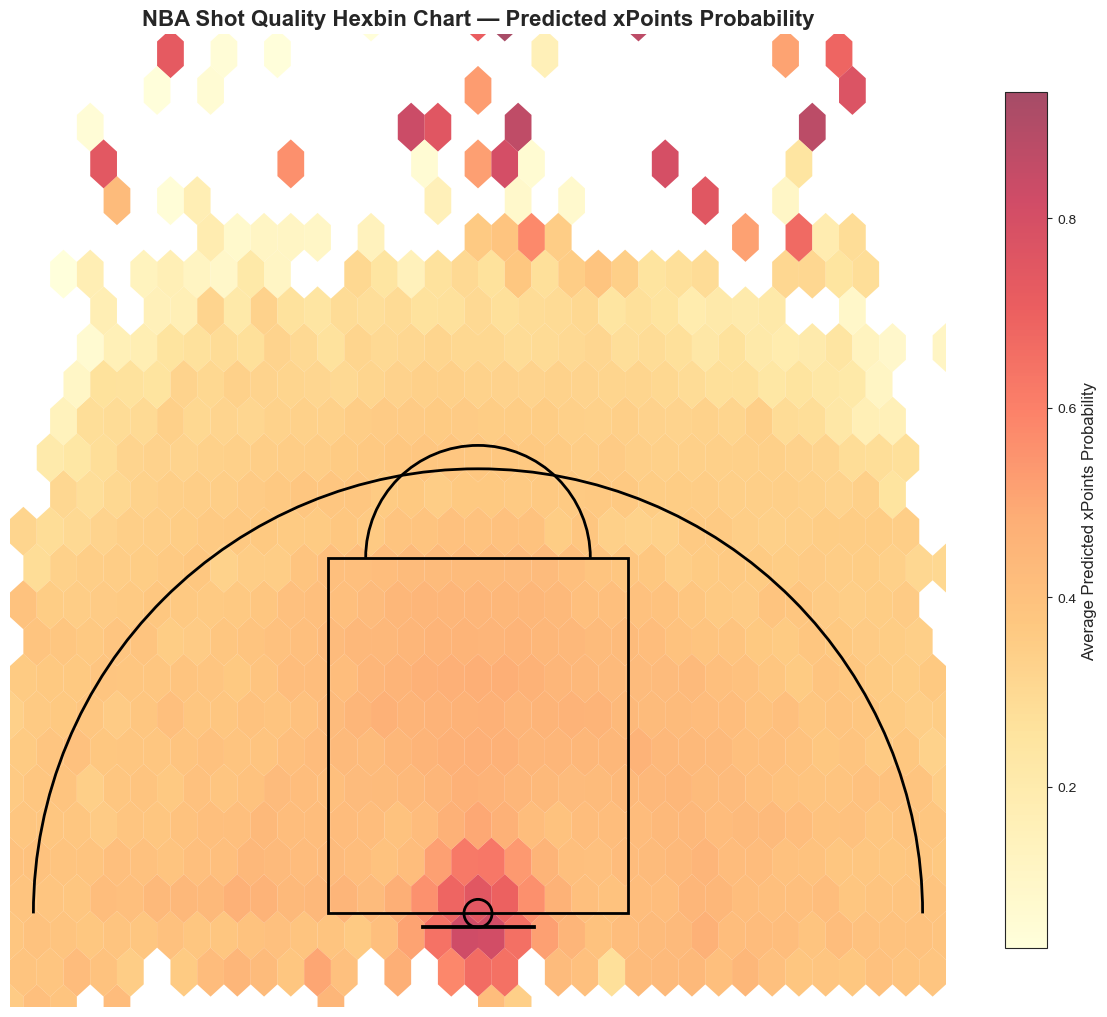

In [8]:
# Import visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle, Arc

# Load the cleaned shot data with LOC_X and LOC_Y available
shots = pd.read_csv('nba_cleaned_shots.csv')

# Recreate the feature matrix used for model probability predictions
feature_columns = [
    'SHOT_DISTANCE',
    'SHOT_ANGLE',
    'TIME_REMAINING_QUARTER',
    'PERIOD',
    'ACTION_TYPE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA'
]
X_full = shots[feature_columns].copy()
X_full = pd.get_dummies(X_full, columns=[
    'ACTION_TYPE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA'
], drop_first=True)

# Use the trained model to predict probability for the whole dataset
shots['xPoints_Probability'] = model.predict_proba(X_full)[:, 1]

# Setup the figure and style for a professional look
sns.set_style('white')
fig, ax = plt.subplots(figsize=(12, 11))

# Helper function to draw the NBA half-court
def draw_half_court(ax):
    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=2, fill=False, color='black')
    # Backboard
    backboard = Rectangle((-30, -7.5), 60, 1, linewidth=2, color='black')
    # Paint
    paint = Rectangle((-80, 0), 160, 190, linewidth=2, fill=False, color='black')
    # Free throw circle
    free_throw = Arc((0, 190), width=120, height=120, theta1=0, theta2=180, linewidth=2, color='black')
    # 3-point arc
    three_point = Arc((0, 0), width=475, height=475, theta1=0, theta2=180, linewidth=2, color='black')
    # Add the court elements
    for element in [hoop, backboard, paint, free_throw, three_point]:
        ax.add_patch(element)
    # Outer boundaries and styling
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 470)
    ax.set_aspect('equal')
    ax.axis('off')

# Draw the court on the axes
draw_half_court(ax)

# Create a hexbin plot overlay using LOC_X, LOC_Y, and predicted probability values
hb = ax.hexbin(
    shots['LOC_X'],
    shots['LOC_Y'],
    C=shots['xPoints_Probability'],
    gridsize=35,
    reduce_C_function=np.mean,
    cmap='YlOrRd',
    mincnt=1,
    edgecolors='none',
    alpha=0.7,
    zorder=0
)

# Add colorbar and titles
cbar = fig.colorbar(hb, ax=ax, shrink=0.8)
cbar.set_label('Average Predicted xPoints Probability', fontsize=12)
ax.set_title('NBA Shot Quality Hexbin Chart — Predicted xPoints Probability', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

In [9]:
import joblib

# This saves your trained XGBoost model as a file
joblib.dump(model, 'nba_shot_quality_model.pkl')

print("Model saved successfully as 'nba_shot_quality_model.pkl'!")

Model saved successfully as 'nba_shot_quality_model.pkl'!
